# Task 2 - Customer Segmentation

## 1. Import Libraries


In [48]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import os


from sklearn.cluster import DBSCAN

## 2. Load the Dataset

In [2]:
df = pd.read_csv("data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Initial Data Inspection
 I first inspect the dataset structure, number of records, data types, missing values, duplicate rows, and basic statistics.

This helps identify any data quality issues before starting the analysis.

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 4. Data Cleaning

The dataset was checked for missing values, duplicate rows, and invalid values.

- No missing values were found.
- No duplicate rows were found.
- The values in Age, Annual Income, and Spending Score are within reasonable ranges.
- CustomerID is an identifier and will not be used as a clustering feature.
- Gender will not be used in the main clustering analysis because the task focuses on Annual Income and Spending Score.

Therefore, no rows need to be removed or imputed at this stage.

## 5. Exploratory Data Analysis

Before applying clustering, I explore the main customer characteristics to understand the distribution of the data and identify any unusual patterns or values.

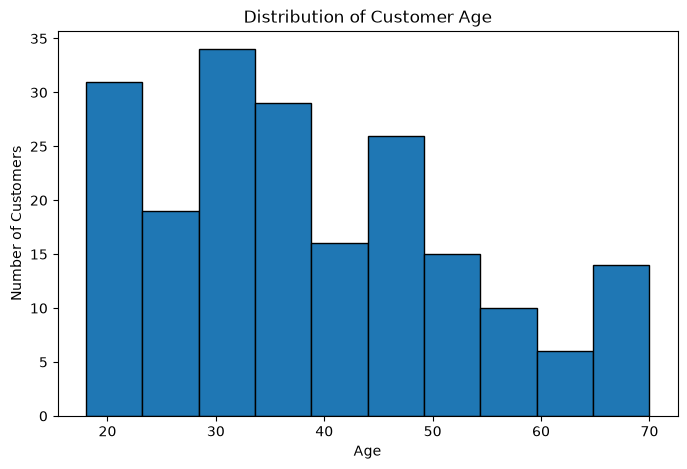

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=10, edgecolor="black")

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Age")

plt.show()

### Age Distribution

The age distribution shows that customers come from a range of age groups, with a higher concentration around young and middle-aged customers. The number of customers generally decreases at older ages.

No clearly invalid age values were observed.

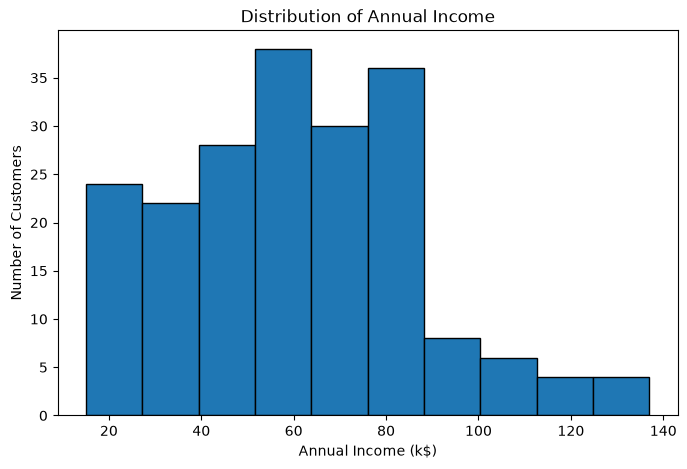

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["Annual Income (k$)"], bins=10, edgecolor="black")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Annual Income")

plt.show()

### Annual Income Distribution

The annual income distribution shows that most customers have incomes between approximately 40k$ and 80k$. There are fewer customers with higher incomes, resulting in a right-skewed distribution.

The high-income values are within the expected range of the dataset, so they will not be removed as invalid values.

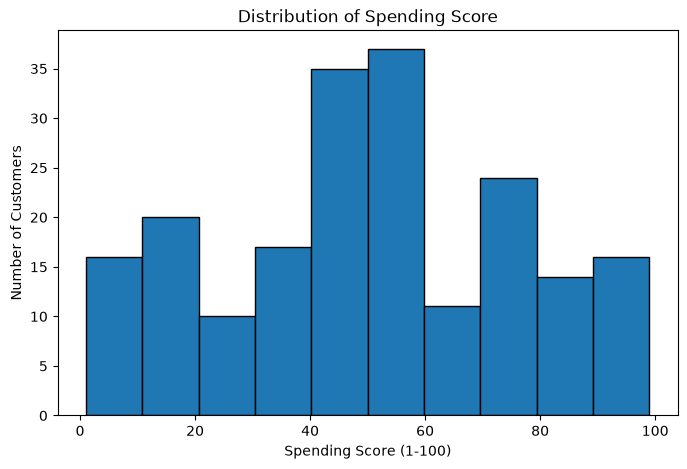

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["Spending Score (1-100)"], bins=10, edgecolor="black")

plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Spending Score")

plt.show()

### Spending Score Distribution

The spending score is distributed across a wide range of values, with a strong concentration around the middle range. There is also a noticeable group of customers with higher spending scores.

This variation in spending behavior makes Spending Score a useful feature for customer segmentation.

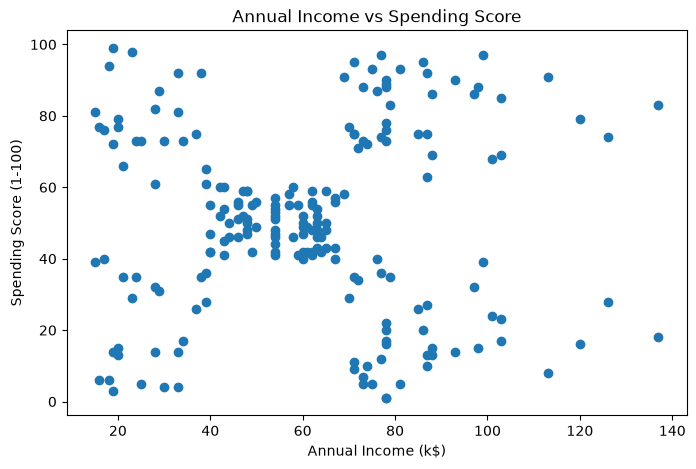

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.show()

### Income vs Spending Score

The scatter plot shows noticeable variation in customer behavior based on annual income and spending score.

Customers can have different combinations of income and spending behavior, suggesting that there may be meaningful customer segments that can be discovered using clustering.

In [12]:
features = df[["Annual Income (k$)", "Spending Score (1-100)"]]

features.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 6. Feature Scaling

K-Means clustering is based on distance calculations. Therefore, the selected features are standardized so that they are on a comparable scale and neither feature dominates the distance calculation.

In [13]:
scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

features_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## 7. Finding the Optimal Number of Clusters

The number of clusters, K, is not chosen randomly. I will evaluate different values of K using the Elbow Method and Silhouette Score to identify a suitable number of customer segments.

In [14]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

inertia

[269.6910121927639,
 157.70400815035947,
 108.92131661364357,
 65.56840815571681,
 55.057348270386,
 44.86475569922556,
 37.228187677585886,
 32.39226763033116,
 29.981897788243693]

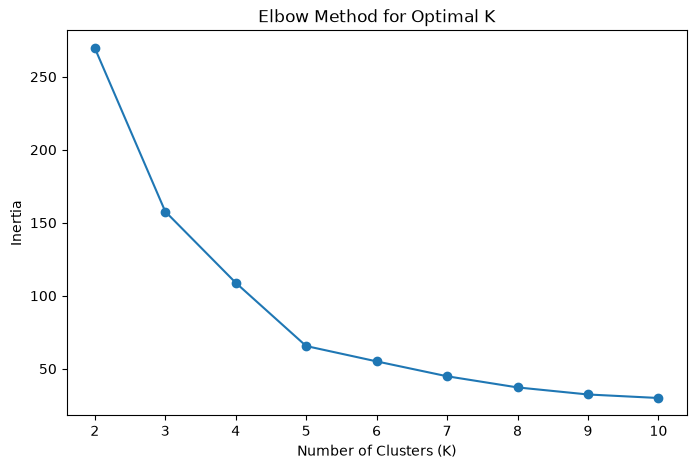

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

### Silhouette Score

The Silhouette Score is used to evaluate how well-separated the clusters are.

A higher score indicates that customers are more similar to the customers within their own cluster and more different from customers in other clusters.

I will compare the Silhouette Score for different values of K.

In [16]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled)
    
    score = silhouette_score(features_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.3212707813918878,
 0.46658474419000145,
 0.4939069237513199,
 0.5546571631111091,
 0.5398800926790663,
 0.5281492781108291,
 0.4552147906587443,
 0.4570853966942764,
 0.4431713026508046]

### 8. Selecting the Best K

The Silhouette Score is used as the main criterion for automatically selecting the optimal number of clusters.

The value of K with the highest Silhouette Score will be selected as the best K.

In [17]:
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]

best_k

5

In [18]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(features_scaled)

In [19]:
cluster_labels[:10]

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2], dtype=int32)

## 9. Assigning Cluster Labels

The cluster labels generated by K-Means are added to the original dataset so that each customer can be associated with a specific customer segment.

In [20]:
df["Cluster"] = cluster_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## 10. Visualizing Customer Segments

The customer segments are visualized using Annual Income and Spending Score.

Each point represents one customer, and the color indicates the cluster assigned by K-Means.

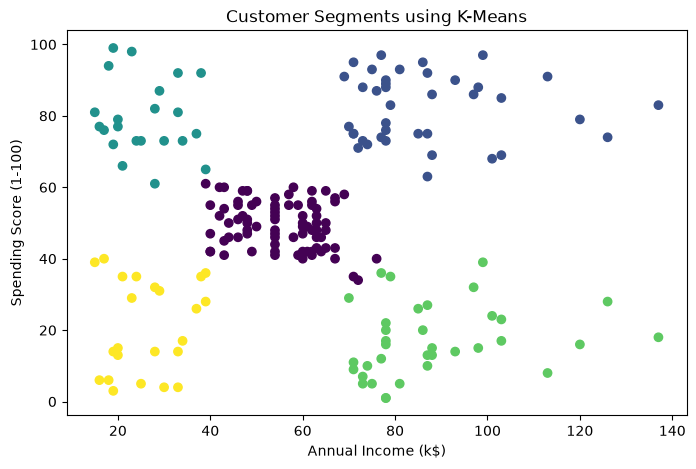

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means")
plt.show()

## 11. Analyzing Customer Segments

To understand the characteristics of each customer segment, I will calculate the average Annual Income and Spending Score for each cluster.

This will help identify the main behavior of each customer group.

In [22]:
cluster_summary = df.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


### Cluster Size

The number of customers in each cluster is calculated to understand the size of each customer segment.

In [23]:
cluster_counts = df["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

### Cluster Interpretation

The clustering results reveal five distinct customer segments:

- **Cluster 0:** Medium-income and medium-spending customers. This is the largest segment, containing 81 customers.
- **Cluster 1:** High-income and high-spending customers. These customers represent a valuable target segment, with 39 customers.
- **Cluster 2:** Low-income but high-spending customers. This group contains 22 customers and shows relatively high spending despite lower income.
- **Cluster 3:** High-income but low-spending customers. This segment contains 35 customers and may represent customers with high purchasing capacity but relatively low engagement.
- **Cluster 4:** Low-income and low-spending customers. This group contains 23 customers and has the lowest average income and spending levels.

Overall, the clustering provides useful customer segments based on income and spending behavior.

## 12. Final Cluster Visualization

The final customer segments are visualized together with the K-Means cluster centers.

The cluster centers are converted back to the original feature scale so they can be displayed in terms of Annual Income and Spending Score.

In [24]:
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)

cluster_centers

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

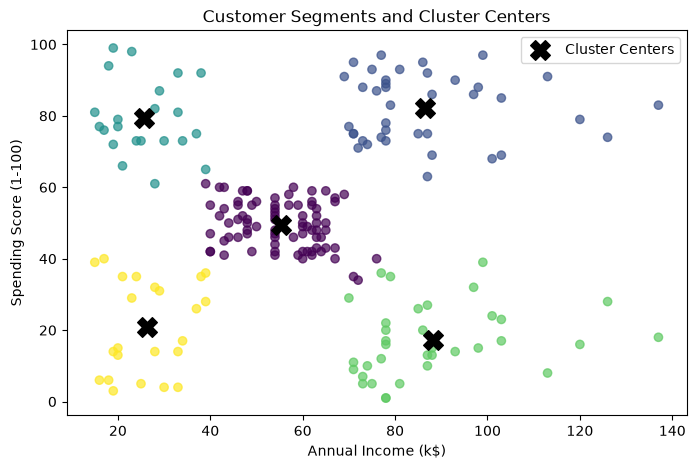

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    cluster_centers[:, 0],
    cluster_centers[:, 1],
    marker="X",
    s=200,
    c="black",
    label="Cluster Centers"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments and Cluster Centers")
plt.legend()
plt.show()

## 13. Business Interpretation

The identified customer segments can help a mall understand different customer behaviors and design more targeted marketing strategies.

- **Average Customers:** Medium-income and medium-spending customers. They represent the largest segment and may respond well to general promotions and loyalty programs.

- **High-Income High-Spending Customers:** These customers have both high income and high spending scores. They may be an important target for premium products, exclusive offers, and personalized marketing.

- **Low-Income High-Spending Customers:** These customers have lower income but relatively high spending scores. They may respond well to attractive promotions, discounts, and products with good value.

- **High-Income Low-Spending Customers:** These customers have high income but low spending scores. They may require more targeted offers or engagement strategies to encourage higher spending.

- **Low-Income Low-Spending Customers:** These customers have both low income and low spending scores. Affordable products, discounts, and value-oriented promotions may be more suitable for this segment.

These interpretations are based only on Annual Income and Spending Score. Other customer characteristics would be needed to understand the reasons behind their behavior.

### Saving the Trained Model

The trained K-Means model and the fitted StandardScaler are saved so they can be reused later in the Streamlit application without retraining the model.

In [49]:
os.makedirs("artifacts", exist_ok=True)

cluster_names = {
    0: "Average Customers",
    1: "High-Income High-Spending Customers",
    2: "Low-Income High-Spending Customers",
    3: "High-Income Low-Spending Customers",
    4: "Low-Income Low-Spending Customers"
}

cluster_descriptions = {
    0: "Medium-income and medium-spending customers.",
    1: "High-income and high-spending customers.",
    2: "Low-income but high-spending customers.",
    3: "High-income but low-spending customers.",
    4: "Low-income and low-spending customers."
}

joblib.dump(
    {
        "model": kmeans,
        "scaler": scaler,
        "cluster_summary": cluster_summary,
        "cluster_counts": cluster_counts,
        "cluster_names": cluster_names,
        "cluster_descriptions": cluster_descriptions
    },
    "artifacts/kmeans_customer_segmentation.pkl"
)

['artifacts/kmeans_customer_segmentation.pkl']

## 14. Bonus: DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm.

Unlike K-Means, DBSCAN does not require specifying the number of clusters in advance. It can also identify data points that do not belong to any dense region as noise.

In this section, different values of `eps` will be tested to determine the parameter setting that produces the best cluster separation based on the Silhouette Score.

In [37]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(features_scaled)

dbscan_labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0, -1, -1,  1, -1, -1, -1, -1, -1, -1])

In [38]:
pd.Series(dbscan_labels).value_counts().sort_index()

-1      8
 0    157
 1     35
Name: count, dtype: int64

### DBSCAN Parameter Tuning

The performance of DBSCAN depends on parameters such as `eps` and `min_samples`.

In this project, `min_samples` is kept fixed at 5, while several values of `eps` are tested.

For each value of `eps`, the number of clusters, number of noise points, and Silhouette Score are calculated.

The Silhouette Score will be used as the main criterion for selecting the best `eps`.

In [39]:
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

dbscan_quality = []

for eps in eps_values:
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = model.fit_predict(features_scaled)
    
    mask = labels != -1
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    
    if n_clusters >= 2:
        score = silhouette_score(
            features_scaled[mask],
            labels[mask]
        )
    else:
        score = None
    
    dbscan_quality.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "silhouette_score": score
    })

dbscan_quality = pd.DataFrame(dbscan_quality)

dbscan_quality

,eps,clusters,noise_points,silhouette_score
0,0.3,7,35,0.524328
1,0.4,4,15,0.478059
2,0.5,2,8,0.387558
3,0.6,1,5,NaN
4,0.7,1,0,NaN
5,0.8,1,0,NaN
6,0.9,1,0,NaN
7,1.0,1,0,NaN


### Selecting the Best `eps`

The value of `eps` with the highest Silhouette Score is selected as the final DBSCAN parameter.

Values that produce only one cluster do not have a meaningful Silhouette Score and are therefore not considered for selection.

In [40]:
valid_results = dbscan_quality.dropna(subset=["silhouette_score"])

best_eps = valid_results.loc[
    valid_results["silhouette_score"].idxmax(),
    "eps"
]

best_eps

np.float64(0.3)

In [41]:
best_dbscan_score = valid_results["silhouette_score"].max()

best_dbscan_score

np.float64(0.5243276105881419)

### Final DBSCAN Model

Based on the Silhouette Score, `eps=0.3` achieved the highest score among the tested values.

Therefore, `eps=0.3` is selected for the final DBSCAN model.

In [42]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(features_scaled)

dbscan_labels

array([ 2,  0,  1,  0,  2,  0,  1, -1,  1,  0, -1, -1, -1,  0,  1,  0,  2,
        0,  2, -1,  2,  0,  1,  0, -1, -1,  2, -1,  2, -1, -1,  0, -1, -1,
       -1, -1, -1,  0, -1,  0,  3, -1,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  4,  3,  4,  3,  4,  5,  4,  5,  4,  3,  4,  5,  4,
        5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  3,  4,  5,  4,  5,  4,  5,
        4,  5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  6,  4,  6,  4,  6, -1,
        6,  4,  6,  4,  6,  4,  6,  4,  6,  4, -1,  4,  6,  4, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [43]:
n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise = (dbscan_labels == -1).sum()

n_clusters, n_noise

(7, np.int64(35))

### DBSCAN Visualization

The final DBSCAN result is visualized using Annual Income and Spending Score.

Customers assigned to `-1` are considered noise points by DBSCAN.

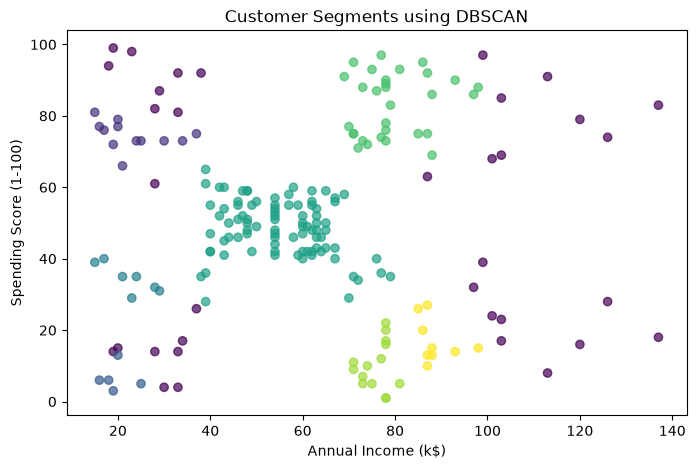

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(
    features["Annual Income (k$)"],
    features["Spending Score (1-100)"],
    c=dbscan_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using DBSCAN")
plt.show()

## 15. DBSCAN Results and Comparison

Using the Silhouette Score as the main selection criterion, `eps=0.3` was chosen for the final DBSCAN model.

This configuration produced seven clusters and identified 35 customers as noise.

The relatively high Silhouette Score indicates good separation among the non-noise clusters. However, the model also classified 35 out of 200 customers as noise.

Compared with K-Means, DBSCAN produced more smaller clusters and identified some customers as noise, while K-Means produced five customer segments without noise points.

For this dataset, K-Means provides a more straightforward business segmentation because its five clusters are easier to interpret based on Annual Income and Spending Score.

DBSCAN is still useful as a comparison because it demonstrates how a density-based algorithm can produce a different view of the customer groups.

In [45]:
comparison = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN"],
    "Number of Clusters": [best_k, n_clusters],
    "Noise Points": [0, n_noise]
})

comparison

,Method,Number of Clusters,Noise Points
0,K-Means,5,0
1,DBSCAN,7,35


## 16. Average Spending per Cluster

The average Spending Score is calculated for each K-Means cluster to better understand the spending behavior of the different customer segments.

In [46]:
average_spending = df.groupby("Cluster")["Spending Score (1-100)"].mean()

average_spending

Cluster
0    49.518519
1    82.128205
2    79.363636
3    17.114286
4    20.913043
Name: Spending Score (1-100), dtype: float64

### Spending Behavior

The results show clear differences in spending behavior across the customer segments.

- **Cluster 1** has the highest average Spending Score at approximately 82.13.
- **Cluster 2** follows with an average Spending Score of approximately 79.36.
- **Cluster 0** has a moderate average Spending Score of approximately 49.52.
- **Cluster 4** has a low average Spending Score of approximately 20.91.
- **Cluster 3** has the lowest average Spending Score at approximately 17.11.

This confirms that the identified clusters have noticeably different spending behaviors.

In [47]:
dbscan_cluster_summary = pd.DataFrame({
    "Cluster": sorted(set(dbscan_labels))
})

dbscan_cluster_summary = dbscan_cluster_summary[
    dbscan_cluster_summary["Cluster"] != -1
]

dbscan_cluster_summary["Number of Customers"] = (
    dbscan_cluster_summary["Cluster"]
    .map(pd.Series(dbscan_labels).value_counts())
)

dbscan_cluster_summary["Average Income (k$)"] = (
    dbscan_cluster_summary["Cluster"]
    .map(df.assign(DBSCAN_Cluster=dbscan_labels)
         .groupby("DBSCAN_Cluster")["Annual Income (k$)"]
         .mean())
)

dbscan_cluster_summary["Average Spending Score"] = (
    dbscan_cluster_summary["Cluster"]
    .map(df.assign(DBSCAN_Cluster=dbscan_labels)
         .groupby("DBSCAN_Cluster")["Spending Score (1-100)"]
         .mean())
)

dbscan_cluster_summary

,Cluster,Number of Customers,Average Income (k$),Average Spending Score
1,0,12,23.166667,74.583333
2,1,5,19.600000,6.600000
3,2,7,22.428571,34.428571
4,3,88,55.227273,48.579545
5,4,30,79.533333,83.133333
6,5,14,75.928571,10.071429
7,6,9,88.777778,17.000000


### DBSCAN Cluster Interpretation

The DBSCAN results show several customer groups based on income and spending behavior:

- **Cluster 0:** Low-income customers with relatively high spending.
- **Cluster 1:** Low-income customers with very low spending.
- **Cluster 2:** Low-income customers with moderate spending.
- **Cluster 3:** Medium-income customers with medium spending. This is the largest DBSCAN cluster.
- **Cluster 4:** High-income customers with high spending.
- **Cluster 5:** High-income customers with very low spending.
- **Cluster 6:** High-income customers with low spending.

DBSCAN also classified 35 customers as noise because they did not belong to sufficiently dense regions according to the selected parameters.

The DBSCAN results provide a more detailed density-based view of the customer data, but some clusters are relatively small. Therefore, K-Means remains easier to interpret for the main business segmentation task.

## 17. Conclusion

This project used customer segmentation techniques to identify groups of mall customers based on Annual Income and Spending Score.

K-Means clustering was used as the main clustering method. The Elbow Method and Silhouette Score were used to determine the optimal number of clusters. Both methods supported selecting `K=5`.

The five K-Means clusters showed clear differences in income and spending behavior, including low-income high-spending customers, high-income high-spending customers, and customers with lower spending levels.

DBSCAN was also applied as a bonus clustering method. Different `eps` values were tested, and `eps=0.3` was selected because it achieved the highest Silhouette Score of approximately `0.5243`. DBSCAN identified seven clusters and 35 noise points.

Although DBSCAN provided additional insights into the density structure of the data, K-Means produced simpler and more interpretable customer segments for the business objective.

Overall, the analysis demonstrates how clustering can be used to understand customer behavior and support more targeted marketing strategies.